In [1]:
import pandas as pd
import numpy as np

In [2]:
# Load the dataset (one folder up from notebooks/, then into data/)

df = pd.read_csv('../data/fraud_data.csv')

print("Shape (row, columns):",df.shape)
df.head()

Shape (row, columns): (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
# fraud vs normal transactions

print("Number of fraud transactions:", df["isFraud"].value_counts()) 

# percentage is fraud
print("Percentage of fraud transactions:", round(df["isFraud"].mean() * 100, 3), "%")

# transaction types does fraud happen in
print("\nFraud transactions by type:")
print(df[df["isFraud"] == 1]["type"].value_counts())


Number of fraud transactions: isFraud
0    6354407
1       8213
Name: count, dtype: int64
Percentage of fraud transactions: 0.129 %

Fraud transactions by type:
type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64


In [7]:

# Keep only the transaction types where fraud can occur
df = df[df["type"].isin(["TRANSFER","CASH_OUT"])].copy()

print("Rows after filtering:",df.shape[0])
print("\nNew Fraud percentage:", round(df["isFraud"].mean() * 100, 3), "%")

Rows after filtering: 2770409

New Fraud percentage: 0.296 %


In [8]:
# Convert transaction type from text to a number
df["type_encoded"] = df["type"].map({"TRANSFER": 0, "CASH_OUT": 1})

# how much sender balanced changed 
df["balance_change_orig"] = df["oldbalanceOrg"] - df["newbalanceOrig"]

# how much receiver balance changed
df["balance_change_dest"] = df["oldbalanceDest"] - df["newbalanceDest"]

#Hour of the day (0-23). 'step' counts total hours, so mod 24 gives time-of-day
df["transaction_hour"] = df["step"] % 24

# Show the new columns alongside isFraud
df[["isFraud", "type_encoded", "balance_change_orig", "balance_change_dest", "transaction_hour"]].head()

,isFraud,type_encoded,balance_change_orig,balance_change_dest,transaction_hour
2,1,0,181.0,0.00,1
3,1,1,181.0,21182.00,1
15,0,1,15325.0,-46430.44,1
19,0,0,705.0,22425.00,1
24,0,0,10835.0,-2712905.89,1


In [9]:
# The columns the model will LEARN FROM (the inputs/clues)
features = [
    "type_encoded",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balance_change_orig",
    "balance_change_dest",
    "transaction_hour",
]

X = df[features]      # X = the inputs (what the model sees)
y = df["isFraud"]     # y = the answer (what we want it to predict)

print("X shape (inputs):", X.shape)
print("y shape (answers):", y.shape)
print("\nFeatures we're using:")
for f in features:
    print(" -", f)

X shape (inputs): (2770409, 9)
y shape (answers): (2770409,)

Features we're using:
 - type_encoded
 - amount
 - oldbalanceOrg
 - newbalanceOrig
 - oldbalanceDest
 - newbalanceDest
 - balance_change_orig
 - balance_change_dest
 - transaction_hour


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # hold back 20% for testing
    random_state=42,    # fixed seed = same split every time
    stratify=y,         # keep the same fraud ratio in both sets
)

print("Training set:", X_train.shape[0], "rows")
print("Test set:    ", X_test.shape[0], "rows")
print("\nFraud % in training:", round(y_train.mean() * 100, 3), "%")
print("Fraud % in test:    ", round(y_test.mean() * 100, 3), "%")

Training set: 2216327 rows
Test set:     554082 rows

Fraud % in training: 0.296 %
Fraud % in test:     0.297 %


In [11]:
from xgboost import XGBClassifier

# Handle the imbalance: count how many normals there are per fraud
fraud_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("Scale pos weight (normals per fraud):", round(fraud_weight, 1))

# Create the model
model = XGBClassifier(
    n_estimators=200,              # build 200 decision trees
    max_depth=6,                   # each tree can ask up to 6 questions deep
    learning_rate=0.1,             # how big each learning step is
    scale_pos_weight=fraud_weight, # tell it fraud is rare & important
    eval_metric="aucpr",           # good scoring metric for imbalanced data
    random_state=42,               # reproducible
    n_jobs=-1,                     # use all CPU cores (faster)
)

# Train it on the training data
model.fit(X_train, y_train)

print("\n Training complete!")

Scale pos weight (normals per fraud): 336.3

 Training complete!


In [12]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Make predictions on the UNSEEN test set
y_pred = model.predict(X_test)                # Fraud (1) or Normal (0)
y_proba = model.predict_proba(X_test)[:, 1]   # fraud probability (0.0 - 1.0)

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

print("=== ROC-AUC Score ===")
print(round(roc_auc_score(y_test, y_proba), 4))

=== Confusion Matrix ===
[[550279   2160]
 [    18   1625]]

=== Classification Report ===
              precision    recall  f1-score   support

           0     1.0000    0.9961    0.9980    552439
           1     0.4293    0.9890    0.5987      1643

    accuracy                         0.9961    554082
   macro avg     0.7146    0.9926    0.7984    554082
weighted avg     0.9983    0.9961    0.9968    554082

=== ROC-AUC Score ===
0.9984


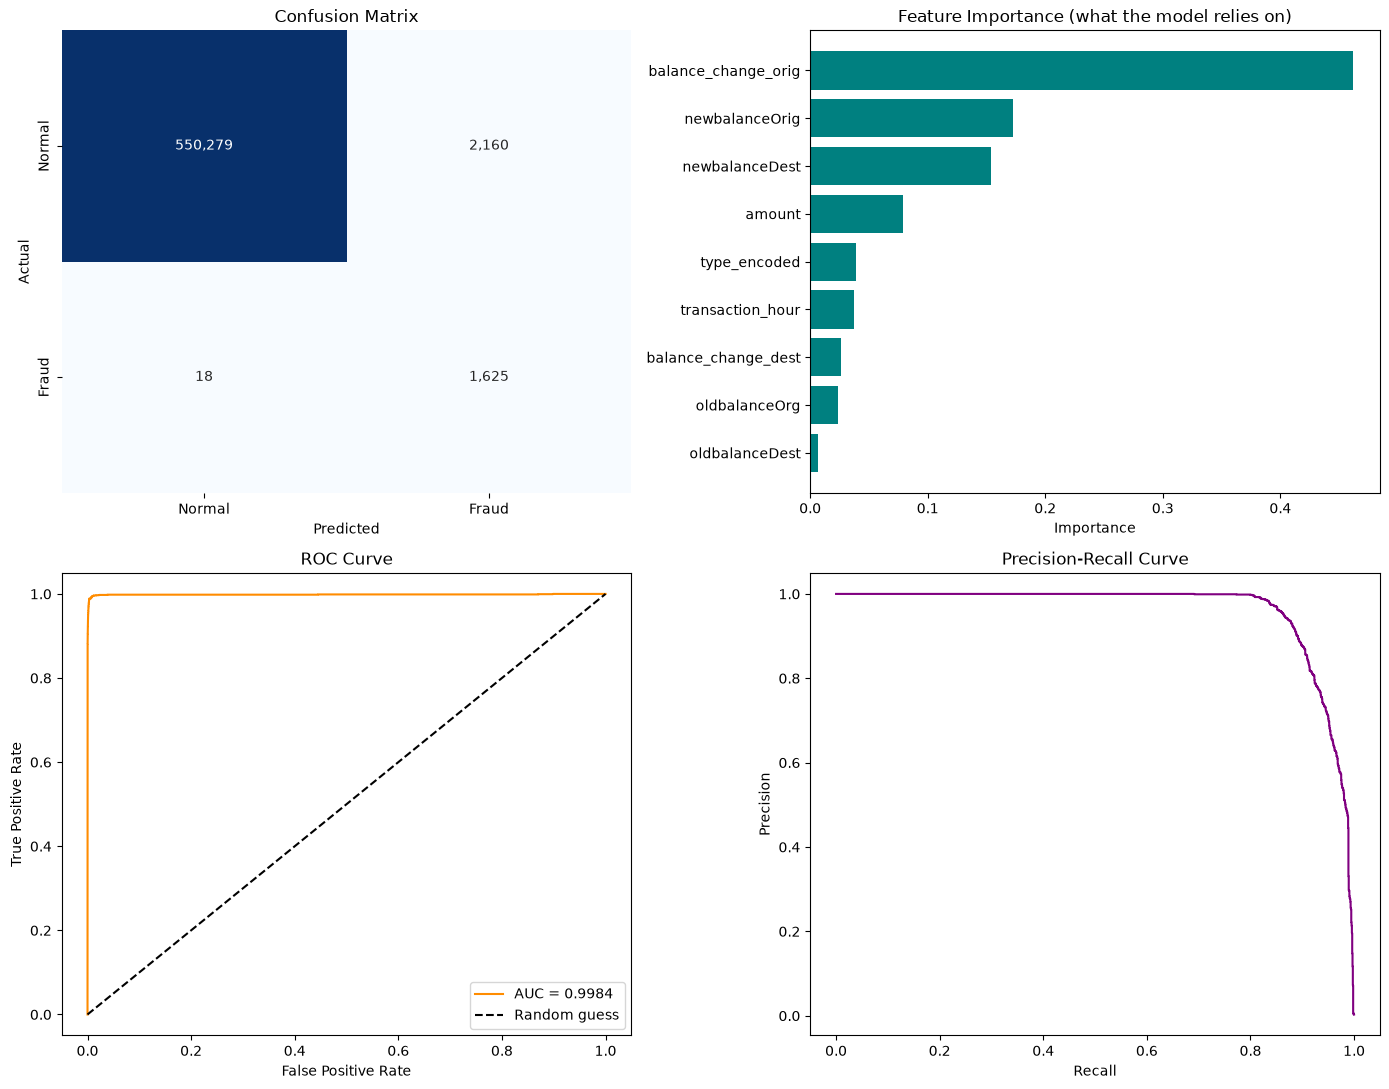

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix

# Set up a 2x2 grid of charts
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# --- Chart 1: Confusion Matrix heatmap ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Normal", "Fraud"],
            yticklabels=["Normal", "Fraud"], ax=axes[0, 0])
axes[0, 0].set_title("Confusion Matrix")
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Actual")

# --- Chart 2: Feature Importance ---
importances = model.feature_importances_
feat_imp = sorted(zip(features, importances), key=lambda x: x[1])
names = [f[0] for f in feat_imp]
vals = [f[1] for f in feat_imp]
axes[0, 1].barh(names, vals, color="teal")
axes[0, 1].set_title("Feature Importance (what the model relies on)")
axes[0, 1].set_xlabel("Importance")

# --- Chart 3: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1, 0].plot(fpr, tpr, color="darkorange", label=f"AUC = {roc_auc_score(y_test, y_proba):.4f}")
axes[1, 0].plot([0, 1], [0, 1], "k--", label="Random guess")
axes[1, 0].set_title("ROC Curve")
axes[1, 0].set_xlabel("False Positive Rate")
axes[1, 0].set_ylabel("True Positive Rate")
axes[1, 0].legend()

# --- Chart 4: Precision-Recall Curve ---
prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[1, 1].plot(rec, prec, color="purple")
axes[1, 1].set_title("Precision-Recall Curve")
axes[1, 1].set_xlabel("Recall")
axes[1, 1].set_ylabel("Precision")

plt.tight_layout()
plt.show()

In [15]:
import joblib
import os

# Save into the ml/ folder (one level up from notebooks/)
joblib.dump(model, "../fraud_model.pkl")
joblib.dump(features, "../feature_names.pkl")

print("Saved:")
print(" - ml/fraud_model.pkl       (the trained model)")
print(" - ml/feature_names.pkl     (the feature order)")
print("\nModel file size:", round(os.path.getsize("../fraud_model.pkl") / 1024, 1), "KB")

Saved:
 - ml/fraud_model.pkl       (the trained model)
 - ml/feature_names.pkl     (the feature order)

Model file size: 739.2 KB
